# Optimization Time Deep-Dive Analysis

Focused analysis on **parameter optimization time** (`opt_time`) — the core likelihood kernel workload — across all backends and GPU optimization stages.

Strips away overhead (alignment loading, setup, I/O) to isolate pure computational performance.

Data sources: `2026_03_13_p6_step` and `2026_03_13_p6_step_fix` (consolidated)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

SAVE_DIR = Path('.')

# Load consolidated data from p6_step_fix analysis (has all backends)
df = pd.read_csv(SAVE_DIR / 'results_all.csv')
df['overhead'] = df['walltime'] - df['opt_time']
df['opt_pct'] = (df['opt_time'] / df['walltime'] * 100)

print(f'Total entries: {len(df)}')
print(f'Backends: {sorted(df["backend"].unique())}')
print(f'Data types: {df["data_type"].unique()}')

Total entries: 1364
Backends: ['GPU_MAXREG', 'GPU_P5', 'GPU_P6', 'GPU_P6_FIX', 'OMP_10', 'OMP_48', 'OPENACC', 'VANILA']
Data types: ['AA' 'DNA']


## 1. Time Breakdown: Optimization Time vs Overhead

How much of the total walltime is spent in parameter optimization (likelihood kernel) vs everything else?

In [2]:
backend_order = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG', 'GPU_P5', 'GPU_P6', 'GPU_P6_FIX']
backend_labels = {
    'VANILA': 'CPU\n1-core', 'OMP_10': 'CPU\n10-core', 'OMP_48': 'CPU\n48-core',
    'OPENACC': 'GPU\nBaseline', 'GPU_MAXREG': 'GPU\nmaxreg',
    'GPU_P5': 'GPU P5\n(Tip State)', 'GPU_P6': 'GPU P6', 'GPU_P6_FIX': 'GPU P6\nFix'
}
backend_colors = {
    'VANILA': '#4C72B0', 'OMP_10': '#55A868', 'OMP_48': '#C44E52',
    'OPENACC': '#DD8452', 'GPU_MAXREG': '#8172B2',
    'GPU_P5': '#CCB974', 'GPU_P6': '#64B5CD', 'GPU_P6_FIX': '#E15759'
}

breakdown = df.groupby(['data_type', 'backend']).agg(
    walltime_median=('walltime', 'median'),
    opt_time_median=('opt_time', 'median'),
    overhead_median=('overhead', 'median'),
    opt_pct_median=('opt_pct', 'median'),
    n=('walltime', 'count')
).round(2).reset_index()

print('=== Time Breakdown (median values) ===')
for dt in ['AA', 'DNA']:
    print(f'\n--- {dt} ---')
    sub = breakdown[breakdown['data_type'] == dt].copy()
    sub['backend_sort'] = sub['backend'].map({b: i for i, b in enumerate(backend_order)})
    sub = sub.sort_values('backend_sort')
    for _, row in sub.iterrows():
        print(f"  {row['backend']:12s}  walltime={row['walltime_median']:7.2f}s  "
              f"opt_time={row['opt_time_median']:7.2f}s  "
              f"overhead={row['overhead_median']:5.2f}s  "
              f"opt%={row['opt_pct_median']:5.1f}%  (n={int(row['n'])})")

=== Time Breakdown (median values) ===

--- AA ---
  VANILA        walltime= 250.29s  opt_time= 247.28s  overhead= 2.99s  opt%= 98.8%  (n=20)
  OMP_10        walltime=  38.56s  opt_time=  37.32s  overhead= 1.28s  opt%= 96.7%  (n=100)
  OMP_48        walltime=  15.02s  opt_time=  13.59s  overhead= 1.39s  opt%= 90.5%  (n=100)
  OPENACC       walltime=  30.60s  opt_time=  27.73s  overhead= 2.88s  opt%= 90.6%  (n=137)
  GPU_MAXREG    walltime=  30.25s  opt_time=  27.39s  overhead= 2.88s  opt%= 90.5%  (n=70)
  GPU_P5        walltime=  18.29s  opt_time=  15.40s  overhead= 2.86s  opt%= 84.3%  (n=99)
  GPU_P6        walltime=  18.31s  opt_time=  15.44s  overhead= 2.85s  opt%= 84.4%  (n=100)
  GPU_P6_FIX    walltime=  18.28s  opt_time=  15.38s  overhead= 2.89s  opt%= 84.2%  (n=98)

--- DNA ---
  VANILA        walltime= 122.00s  opt_time= 119.26s  overhead= 2.69s  opt%= 97.8%  (n=40)
  OMP_10        walltime=  34.24s  opt_time=  33.17s  overhead= 1.08s  opt%= 96.2%  (n=100)
  OMP_48        wallt

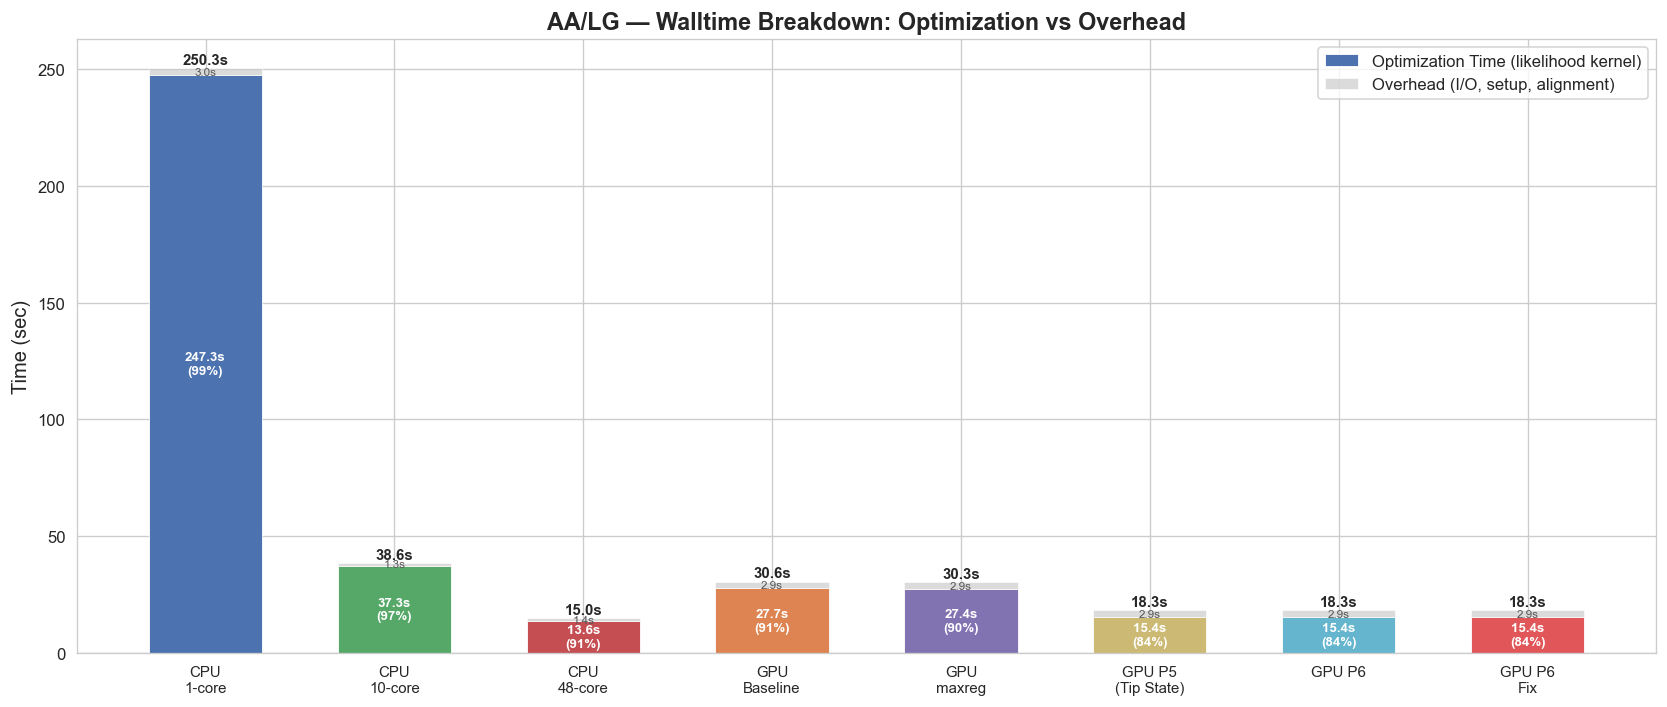

Saved: opt_breakdown_AA_LG.png


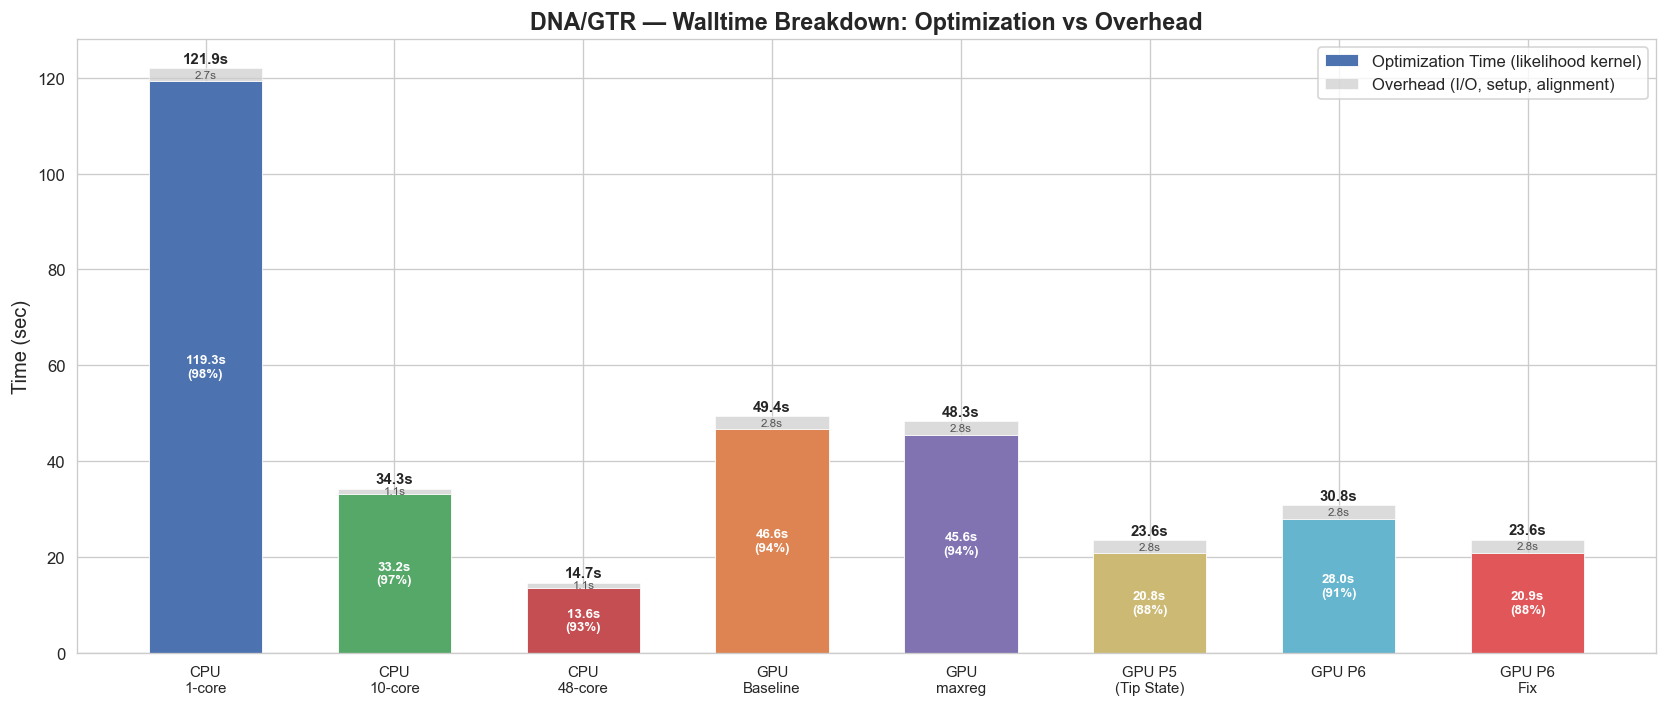

Saved: opt_breakdown_DNA_GTR.png


In [3]:
# Stacked bar chart: opt_time + overhead
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model)]
    present = [b for b in backend_order if b in subset['backend'].unique()]
    
    med_opt = subset.groupby('backend')['opt_time'].median().reindex(present)
    med_overhead = subset.groupby('backend')['overhead'].median().reindex(present)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(present))
    
    bars_opt = ax.bar(x, med_opt.values, width=0.6, 
                       color=[backend_colors[b] for b in present],
                       label='Optimization Time (likelihood kernel)', edgecolor='white', linewidth=0.5)
    bars_oh = ax.bar(x, med_overhead.values, bottom=med_opt.values, width=0.6,
                      color='#CCCCCC', label='Overhead (I/O, setup, alignment)', 
                      edgecolor='white', linewidth=0.5, alpha=0.7)
    
    # Annotate opt_time and overhead
    for i, b in enumerate(present):
        opt_val = med_opt[b]
        oh_val = med_overhead[b]
        total = opt_val + oh_val
        pct = opt_val / total * 100
        ax.text(i, opt_val / 2, f'{opt_val:.1f}s\n({pct:.0f}%)',
               ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        ax.text(i, opt_val + oh_val / 2, f'{oh_val:.1f}s',
               ha='center', va='center', fontsize=7, color='#555555')
        ax.text(i, total + 0.5, f'{total:.1f}s', ha='center', va='bottom',
               fontsize=9, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
    ax.set_ylabel('Time (sec)', fontsize=12)
    ax.set_title(f'{data_type}/{model} — Walltime Breakdown: Optimization vs Overhead',
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    plt.tight_layout()
    fname = f'opt_breakdown_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 2. Pure Optimization Time — All Backends

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/3656978107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/3656978107.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)


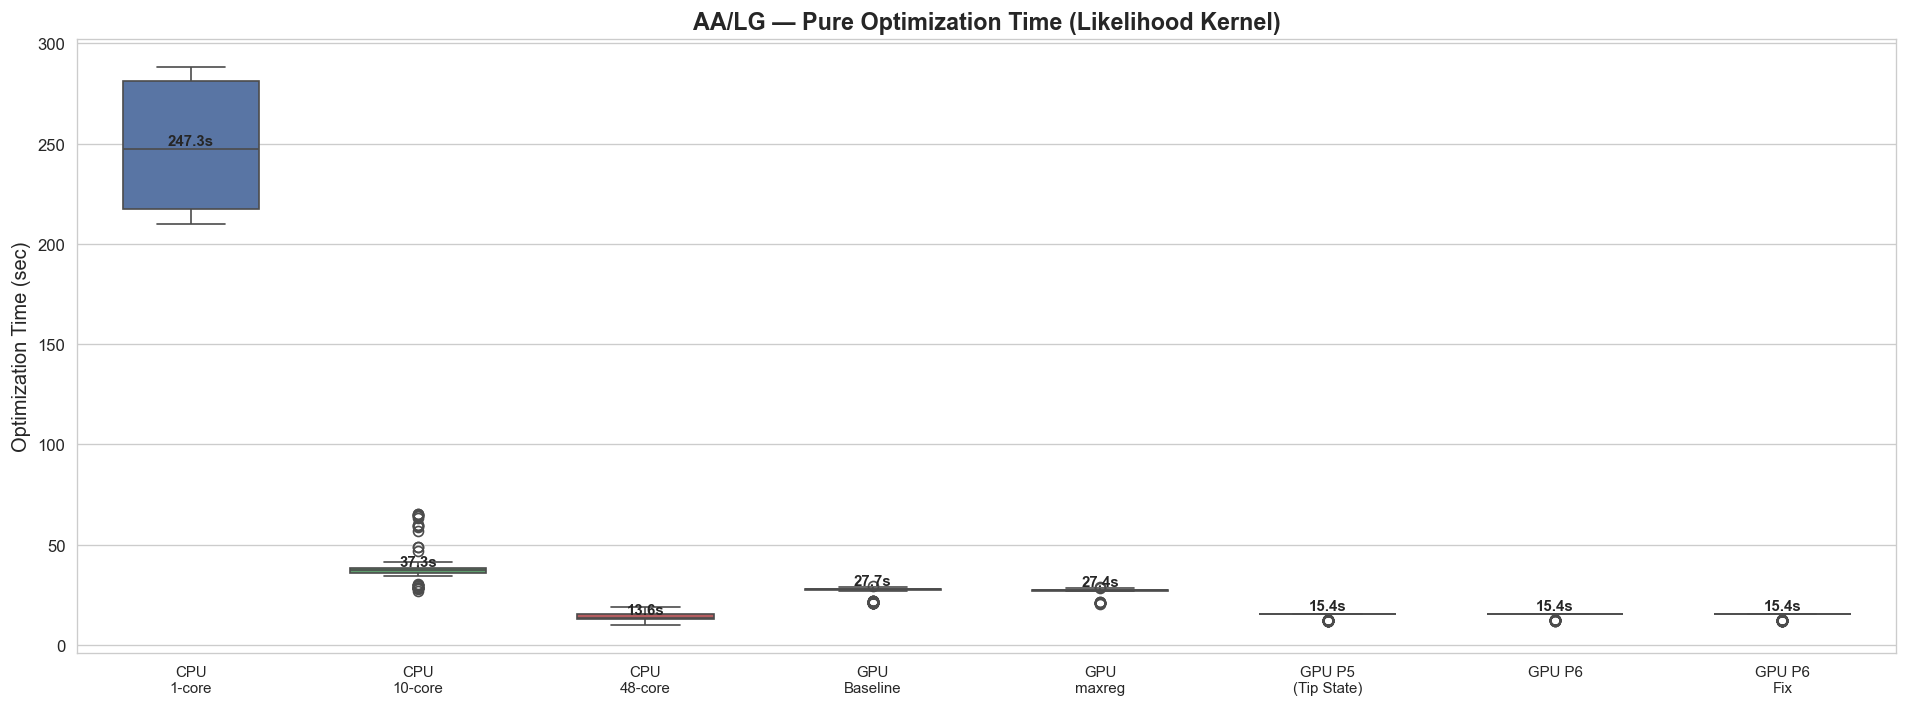

Saved: opt_time_all_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/3656978107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/3656978107.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)


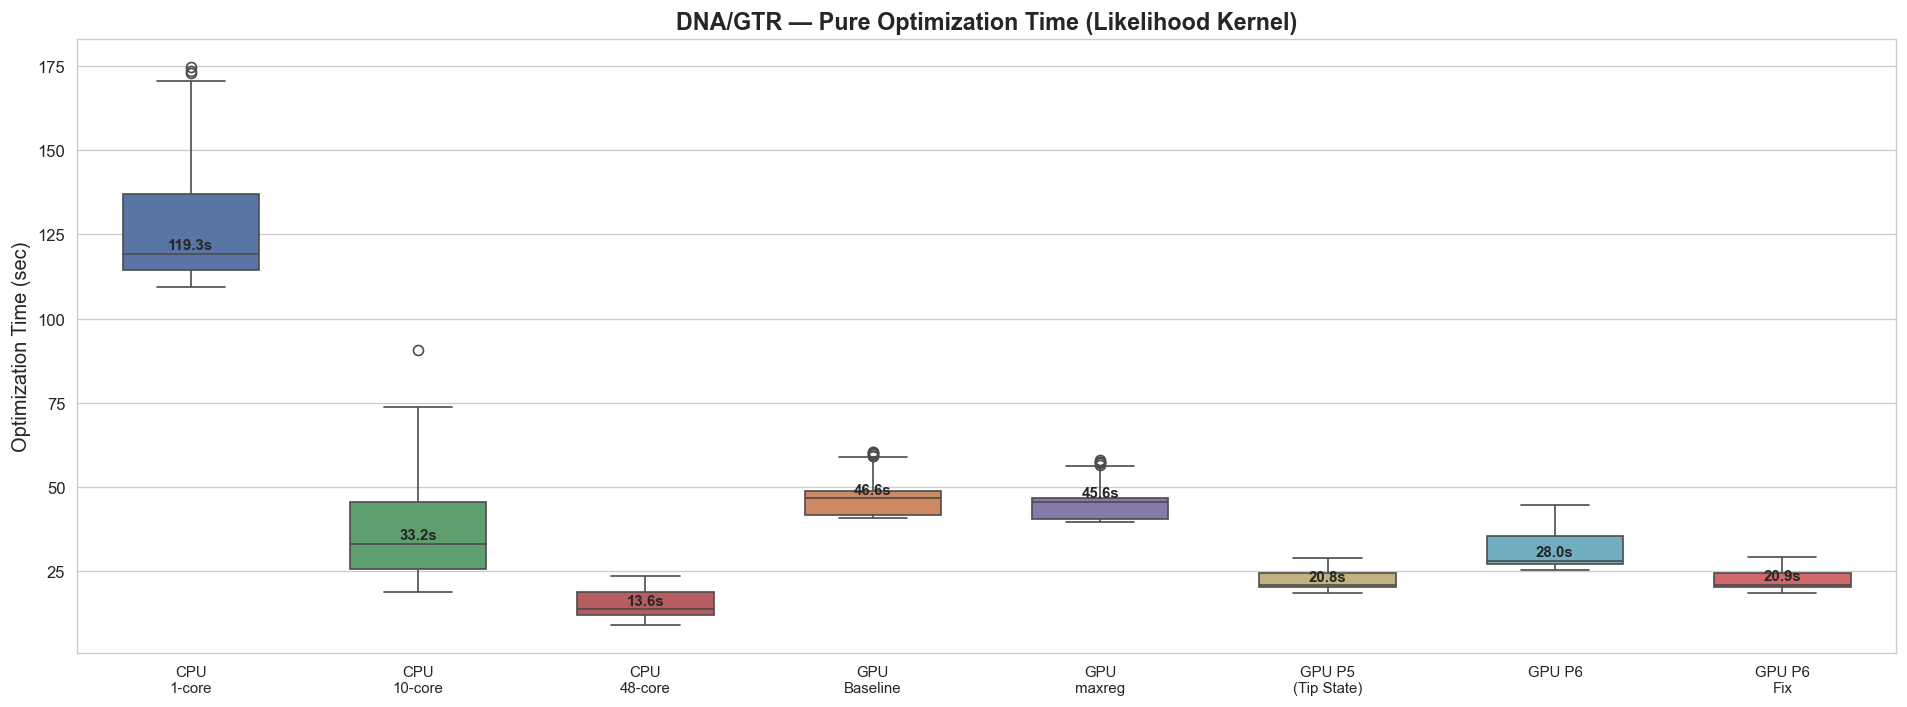

Saved: opt_time_all_DNA_GTR.png


In [4]:
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model)]
    present = [b for b in backend_order if b in subset['backend'].unique()]
    palette = [backend_colors[b] for b in present]
    
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=present, palette=palette, ax=ax, width=0.6)
    
    ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
    ax.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} — Pure Optimization Time (Likelihood Kernel)',
                fontsize=14, fontweight='bold')
    
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax.text(i, medians[b] + 0.5, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    fname = f'opt_time_all_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 3. Optimization Time Speedup vs CPU 1-core

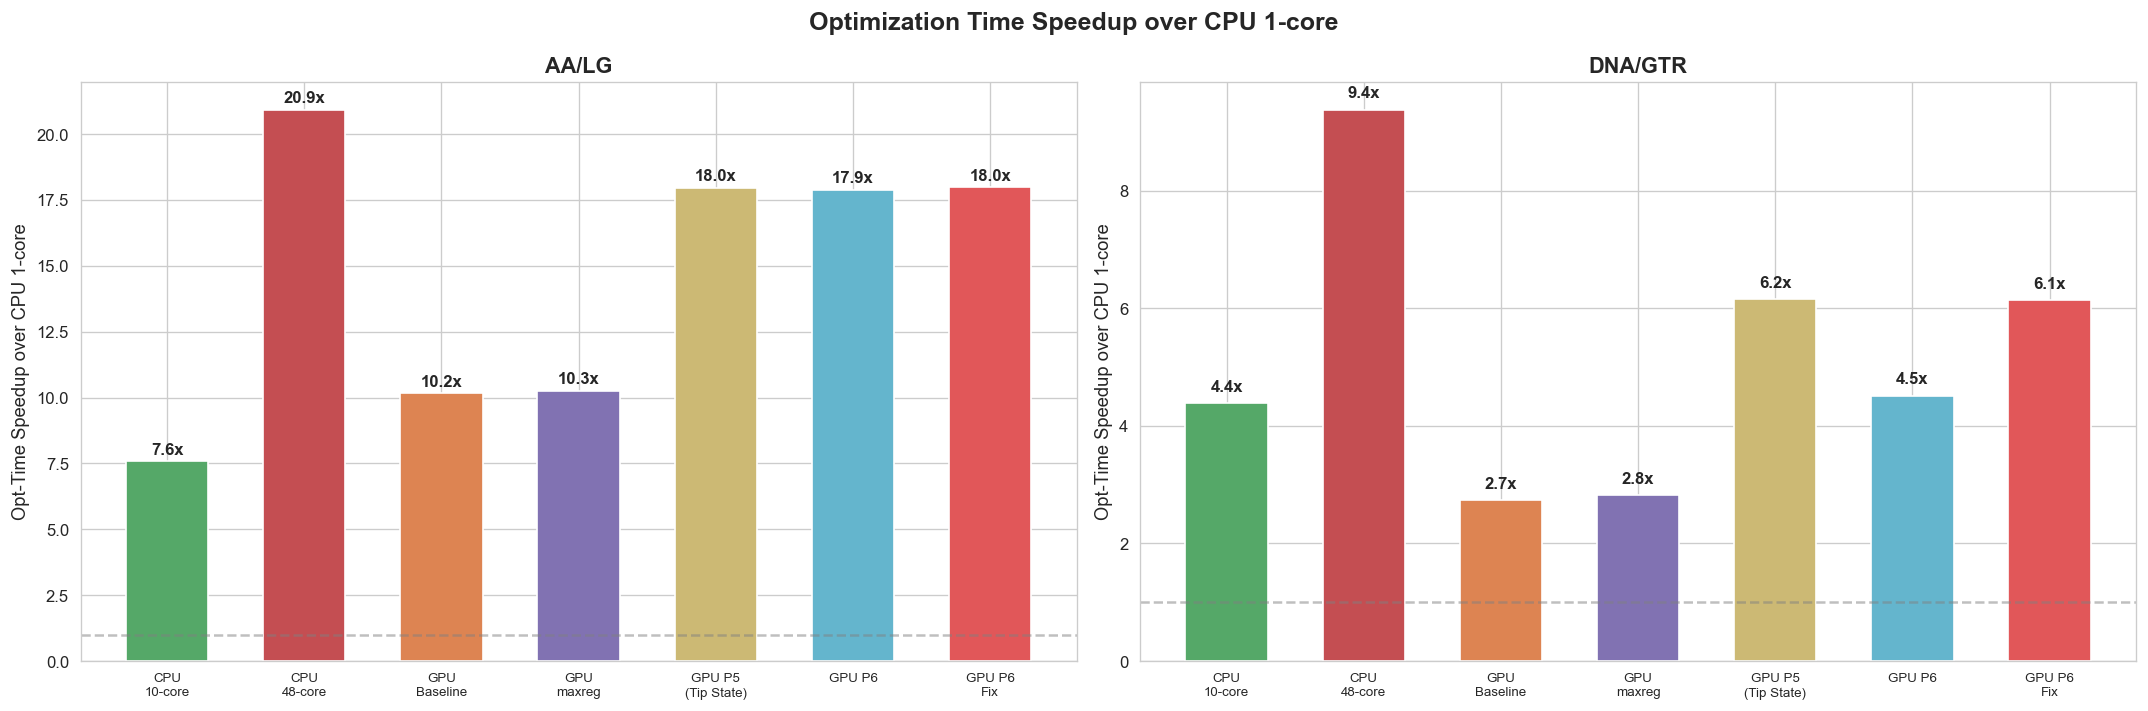

In [5]:
# Speedup based on opt_time
med_opt = df.groupby(['data_type', 'model', 'tree', 'backend'])['opt_time'].median().reset_index()
pivot_opt = med_opt.pivot_table(index=['data_type', 'model', 'tree'],
                                 columns='backend', values='opt_time').reset_index()

for b in ['OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG', 'GPU_P5', 'GPU_P6', 'GPU_P6_FIX']:
    if b in pivot_opt.columns and 'VANILA' in pivot_opt.columns:
        pivot_opt[f'speedup_{b}'] = pivot_opt['VANILA'] / pivot_opt[b]

pivot_opt.to_csv(SAVE_DIR / 'opt_time_speedup_pivot.csv', index=False)

speedup_backends = ['OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG', 'GPU_P5', 'GPU_P6', 'GPU_P6_FIX']
bar_colors = ['#55A868', '#C44E52', '#DD8452', '#8172B2', '#CCB974', '#64B5CD', '#E15759']
bar_labels = ['CPU\n10-core', 'CPU\n48-core', 'GPU\nBaseline', 'GPU\nmaxreg', 'GPU P5\n(Tip State)', 'GPU P6', 'GPU P6\nFix']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, (data_type, model) in zip(axes, [('AA', 'LG'), ('DNA', 'GTR')]):
    sub = pivot_opt[(pivot_opt['data_type'] == data_type) & (pivot_opt['model'] == model)]
    present_cols, present_colors, present_labels = [], [], []
    for b, c, l in zip(speedup_backends, bar_colors, bar_labels):
        col = f'speedup_{b}'
        if col in sub.columns and sub[col].notna().any():
            present_cols.append(col)
            present_colors.append(c)
            present_labels.append(l)
    
    means = [sub[c].mean() for c in present_cols]
    bars = ax.bar(range(len(present_cols)), means, color=present_colors, width=0.6)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
               f'{val:.1f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(present_cols)))
    ax.set_xticklabels(present_labels, fontsize=8)
    ax.set_ylabel('Opt-Time Speedup over CPU 1-core', fontsize=11)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{data_type}/{model}', fontsize=13, fontweight='bold')

fig.suptitle('Optimization Time Speedup over CPU 1-core', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'opt_time_speedup_vs_1core.png', bbox_inches='tight')
plt.show()

## 4. GPU vs CPU 48-core — Optimization Time Head-to-Head

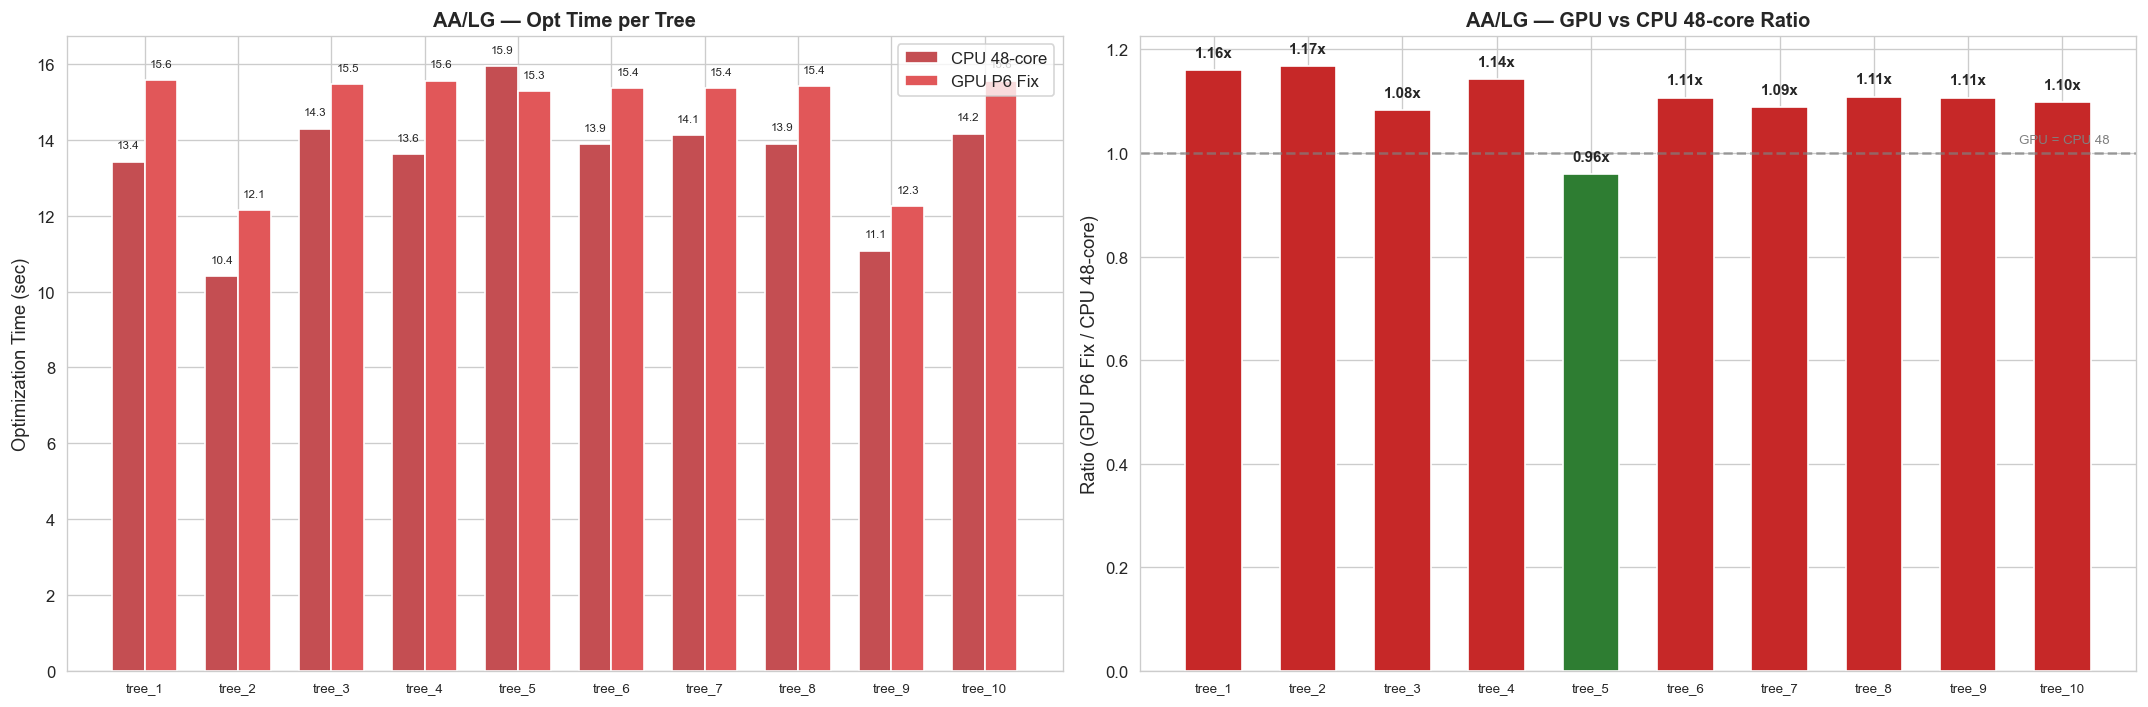

Saved: opt_gpu_vs_cpu48_AA_LG.png
AA/LG: GPU P6 Fix opt_time is 1.10x of CPU 48-core (mean across trees)
  -> GPU is 10% SLOWER than CPU 48-core in pure optimization


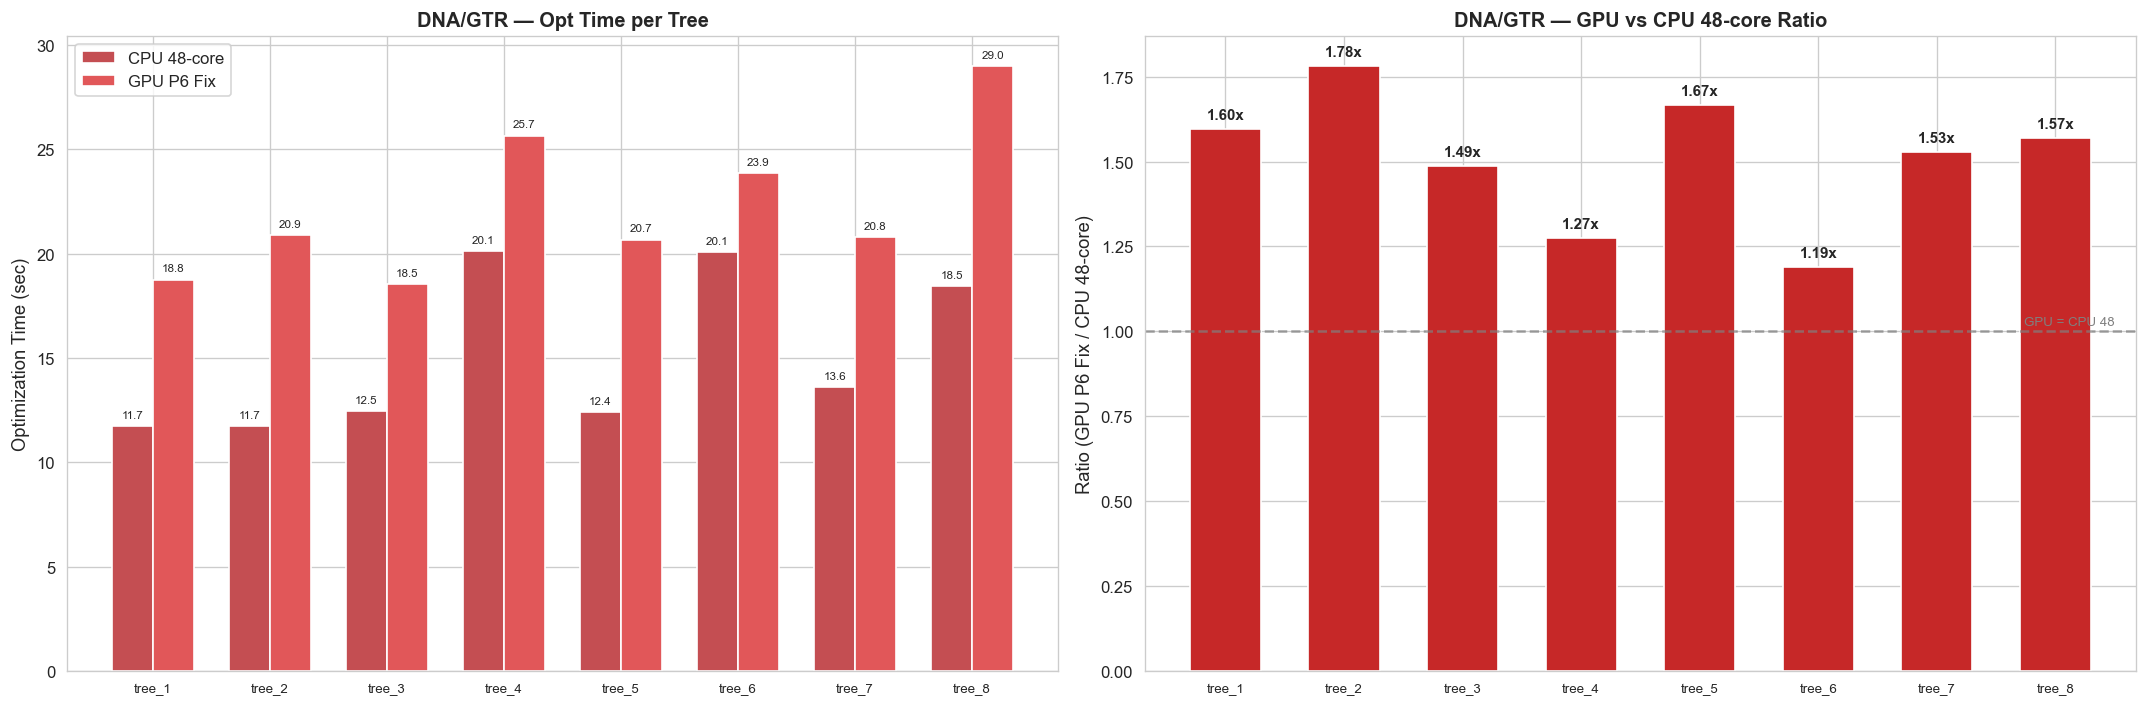

Saved: opt_gpu_vs_cpu48_DNA_GTR.png
DNA/GTR: GPU P6 Fix opt_time is 1.51x of CPU 48-core (mean across trees)
  -> GPU is 51% SLOWER than CPU 48-core in pure optimization


In [6]:
# Direct comparison: GPU P6Fix vs CPU 48-core opt_time per tree
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    sub = pivot_opt[(pivot_opt['data_type'] == data_type) & (pivot_opt['model'] == model)].copy()
    if 'GPU_P6_FIX' not in sub.columns or 'OMP_48' not in sub.columns:
        continue
    
    # Only trees where both exist
    sub = sub.dropna(subset=['GPU_P6_FIX', 'OMP_48'])
    trees = sorted(sub['tree'].values, key=lambda x: int(x.split('_')[1]))
    sub = sub.set_index('tree').loc[trees]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # Left: side-by-side bars
    x = np.arange(len(trees))
    w = 0.35
    bars1 = ax1.bar(x - w/2, sub['OMP_48'].values, w, color='#C44E52', label='CPU 48-core')
    bars2 = ax1.bar(x + w/2, sub['GPU_P6_FIX'].values, w, color='#E15759', label='GPU P6 Fix')
    
    for i, (c48, gfix) in enumerate(zip(sub['OMP_48'].values, sub['GPU_P6_FIX'].values)):
        ax1.text(i - w/2, c48 + 0.3, f'{c48:.1f}', ha='center', va='bottom', fontsize=7)
        ax1.text(i + w/2, gfix + 0.3, f'{gfix:.1f}', ha='center', va='bottom', fontsize=7)
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(trees, fontsize=8)
    ax1.set_ylabel('Optimization Time (sec)', fontsize=11)
    ax1.set_title(f'{data_type}/{model} — Opt Time per Tree', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    
    # Right: ratio (GPU / CPU48)
    ratio = sub['GPU_P6_FIX'] / sub['OMP_48']
    colors = ['#C62828' if r > 1 else '#2E7D32' for r in ratio.values]
    bars = ax2.bar(x, ratio.values, color=colors, width=0.6)
    for i, r in enumerate(ratio.values):
        label = f'{r:.2f}x' if r >= 1 else f'{r:.2f}x'
        ax2.text(i, r + 0.02, label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7)
    ax2.text(len(trees) - 0.5, 1.02, 'GPU = CPU 48', fontsize=8, color='gray', ha='right')
    ax2.set_xticks(x)
    ax2.set_xticklabels(trees, fontsize=8)
    ax2.set_ylabel('Ratio (GPU P6 Fix / CPU 48-core)', fontsize=11)
    ax2.set_title(f'{data_type}/{model} — GPU vs CPU 48-core Ratio', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    fname = f'opt_gpu_vs_cpu48_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')
    
    mean_ratio = ratio.mean()
    print(f'{data_type}/{model}: GPU P6 Fix opt_time is {mean_ratio:.2f}x of CPU 48-core (mean across trees)')
    if mean_ratio > 1:
        print(f'  -> GPU is {(mean_ratio - 1) * 100:.0f}% SLOWER than CPU 48-core in pure optimization')
    else:
        print(f'  -> GPU is {(1 - mean_ratio) * 100:.0f}% faster than CPU 48-core in pure optimization')

## 5. GPU Evolution — Optimization Time Only

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/2382340034.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/2382340034.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p_labels, fontsize=10)


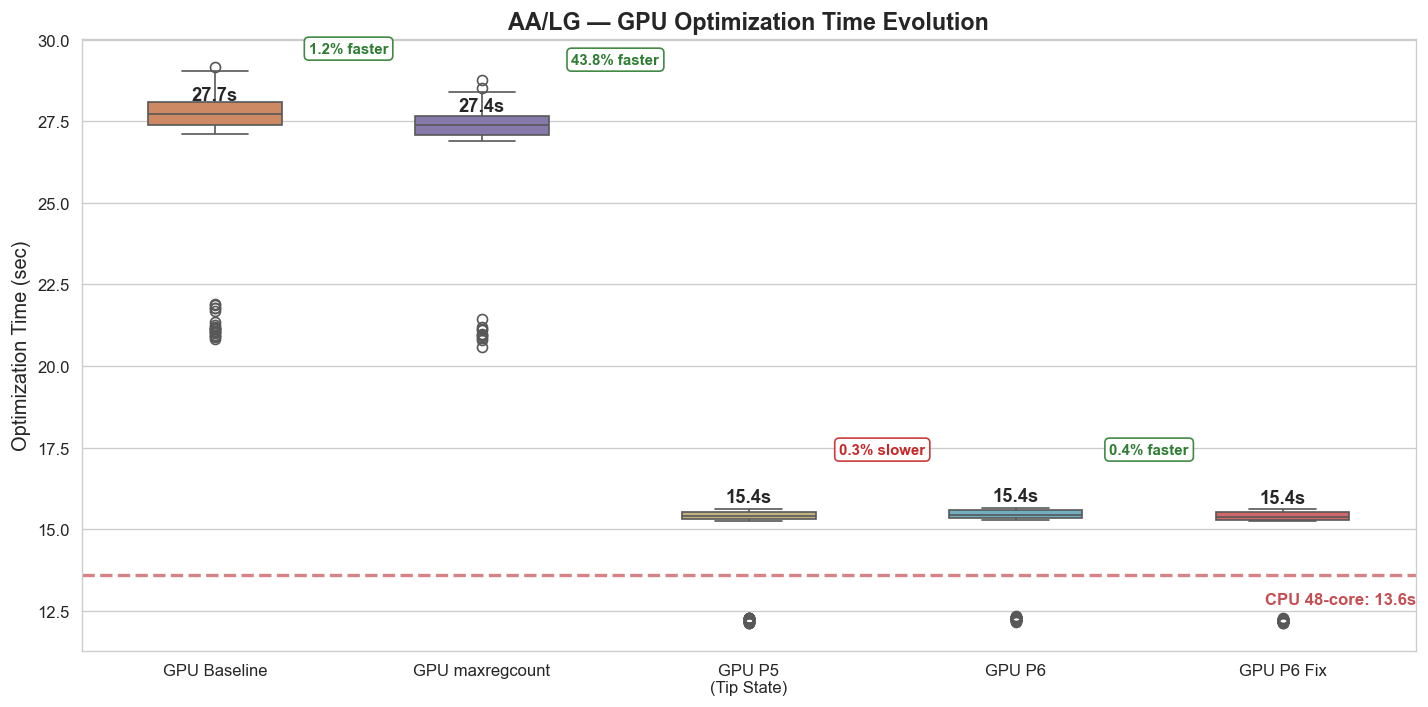

Saved: opt_gpu_evolution_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/2382340034.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/2382340034.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p_labels, fontsize=10)


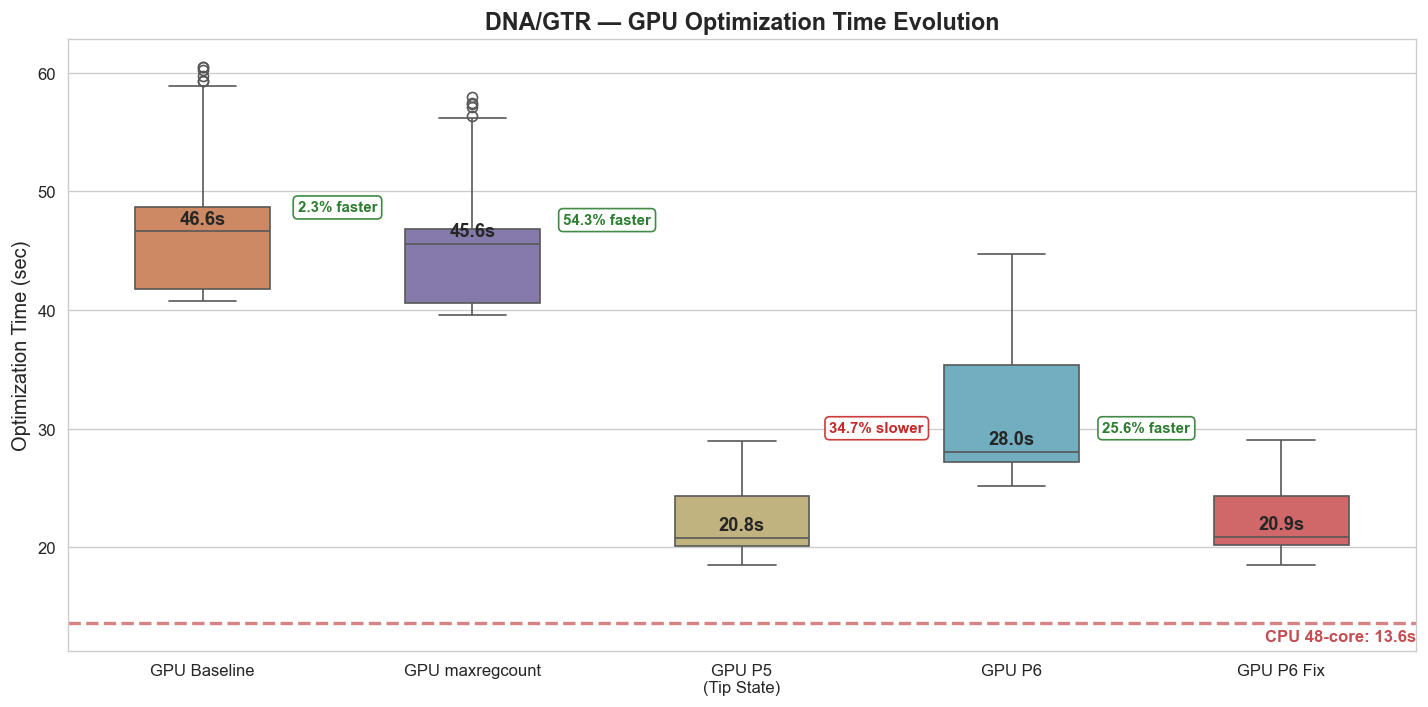

Saved: opt_gpu_evolution_DNA_GTR.png


In [7]:
gpu_order = ['OPENACC', 'GPU_MAXREG', 'GPU_P5', 'GPU_P6', 'GPU_P6_FIX']
gpu_labels = ['GPU Baseline', 'GPU maxregcount', 'GPU P5\n(Tip State)', 'GPU P6', 'GPU P6 Fix']
gpu_colors = ['#DD8452', '#8172B2', '#CCB974', '#64B5CD', '#E15759']

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(gpu_order)]
    present = [b for b in gpu_order if b in subset['backend'].unique()]
    p_colors = [gpu_colors[gpu_order.index(b)] for b in present]
    p_labels = [gpu_labels[gpu_order.index(b)] for b in present]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=present, palette=p_colors, ax=ax, width=0.5)
    
    ax.set_xticklabels(p_labels, fontsize=10)
    ax.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} — GPU Optimization Time Evolution',
                fontsize=14, fontweight='bold')
    
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax.text(i, medians[b] + 0.3, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Improvement annotations
    for i in range(len(present) - 1):
        if present[i] in medians.index and present[i+1] in medians.index:
            m1, m2 = medians[present[i]], medians[present[i+1]]
            pct = (m1 - m2) / m1 * 100
            mid_y = max(m1, m2) + 2
            color = '#2E7D32' if pct > 0 else '#C62828'
            label = f'{pct:.1f}% faster' if pct > 0 else f'{abs(pct):.1f}% slower'
            ax.annotate(label,
                       xy=(i + 0.5, mid_y), fontsize=9, fontweight='bold',
                       ha='center', va='center', color=color,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9))
    
    # Add CPU 48-core reference line
    cpu48 = df[(df['data_type'] == data_type) & (df['model'] == model) & 
               (df['backend'] == 'OMP_48')]['opt_time'].median()
    ax.axhline(y=cpu48, color='#C44E52', linestyle='--', alpha=0.7, linewidth=2)
    ax.text(len(present) - 0.5, cpu48 - 0.5, f'CPU 48-core: {cpu48:.1f}s',
           fontsize=10, color='#C44E52', fontweight='bold', ha='right', va='top')
    
    plt.tight_layout()
    fname = f'opt_gpu_evolution_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 6. Overhead Analysis — GPU vs CPU

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/3186779111.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='overhead',


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/3186779111.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)


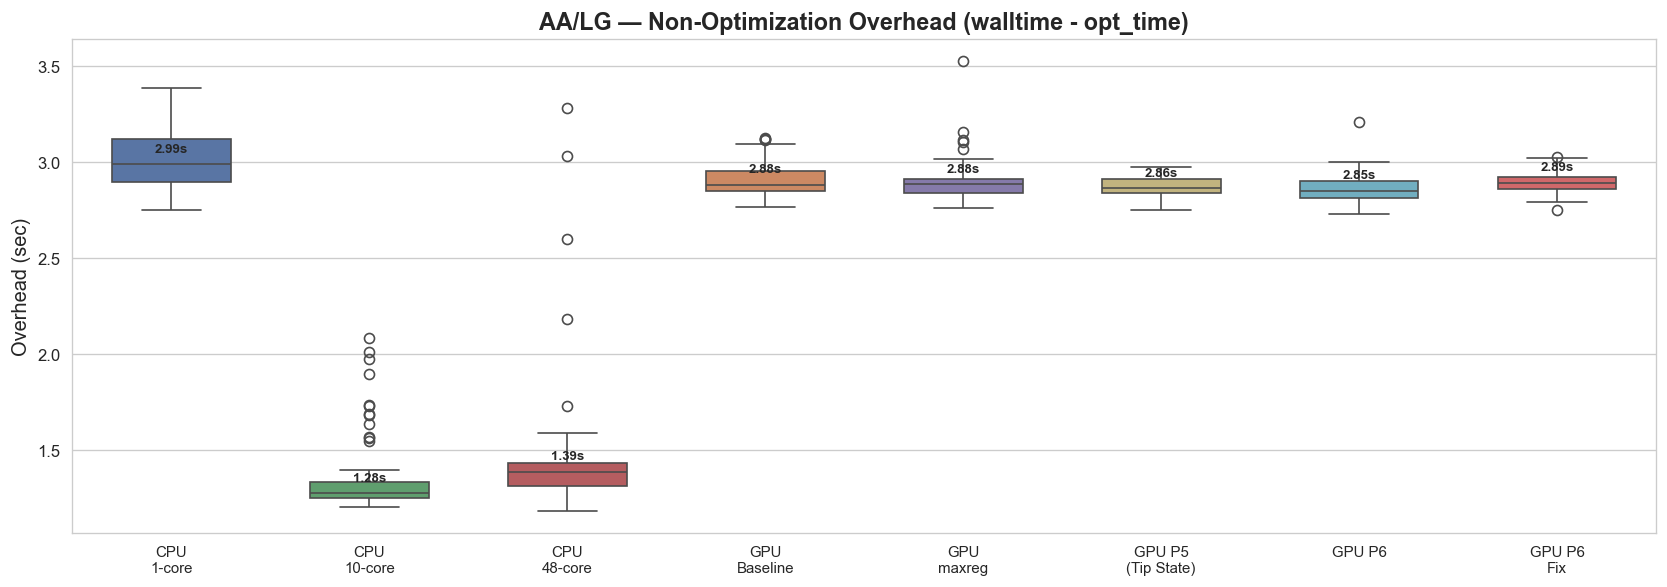

Saved: overhead_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/3186779111.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='overhead',


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/3186779111.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)


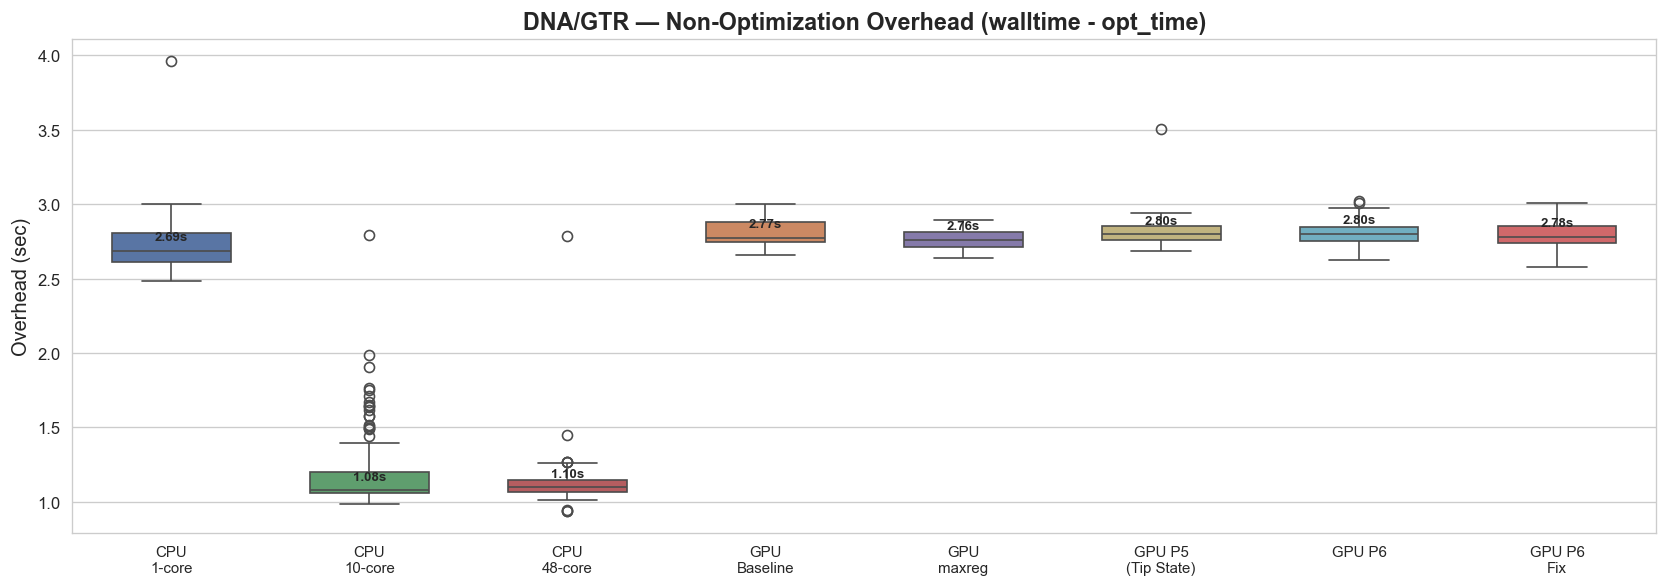

Saved: overhead_DNA_GTR.png


In [8]:
# Overhead = walltime - opt_time (setup, alignment loading, GPU init, data transfer)
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model)]
    present = [b for b in backend_order if b in subset['backend'].unique()]
    palette = [backend_colors[b] for b in present]
    
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(data=subset, x='backend', y='overhead',
               order=present, palette=palette, ax=ax, width=0.6)
    
    ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
    ax.set_ylabel('Overhead (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} — Non-Optimization Overhead (walltime - opt_time)',
                fontsize=14, fontweight='bold')
    
    medians = subset.groupby('backend')['overhead'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax.text(i, medians[b] + 0.05, f'{medians[b]:.2f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    plt.tight_layout()
    fname = f'overhead_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 7. Per-Tree Optimization Time — GPU P5 vs P6 vs P6 Fix

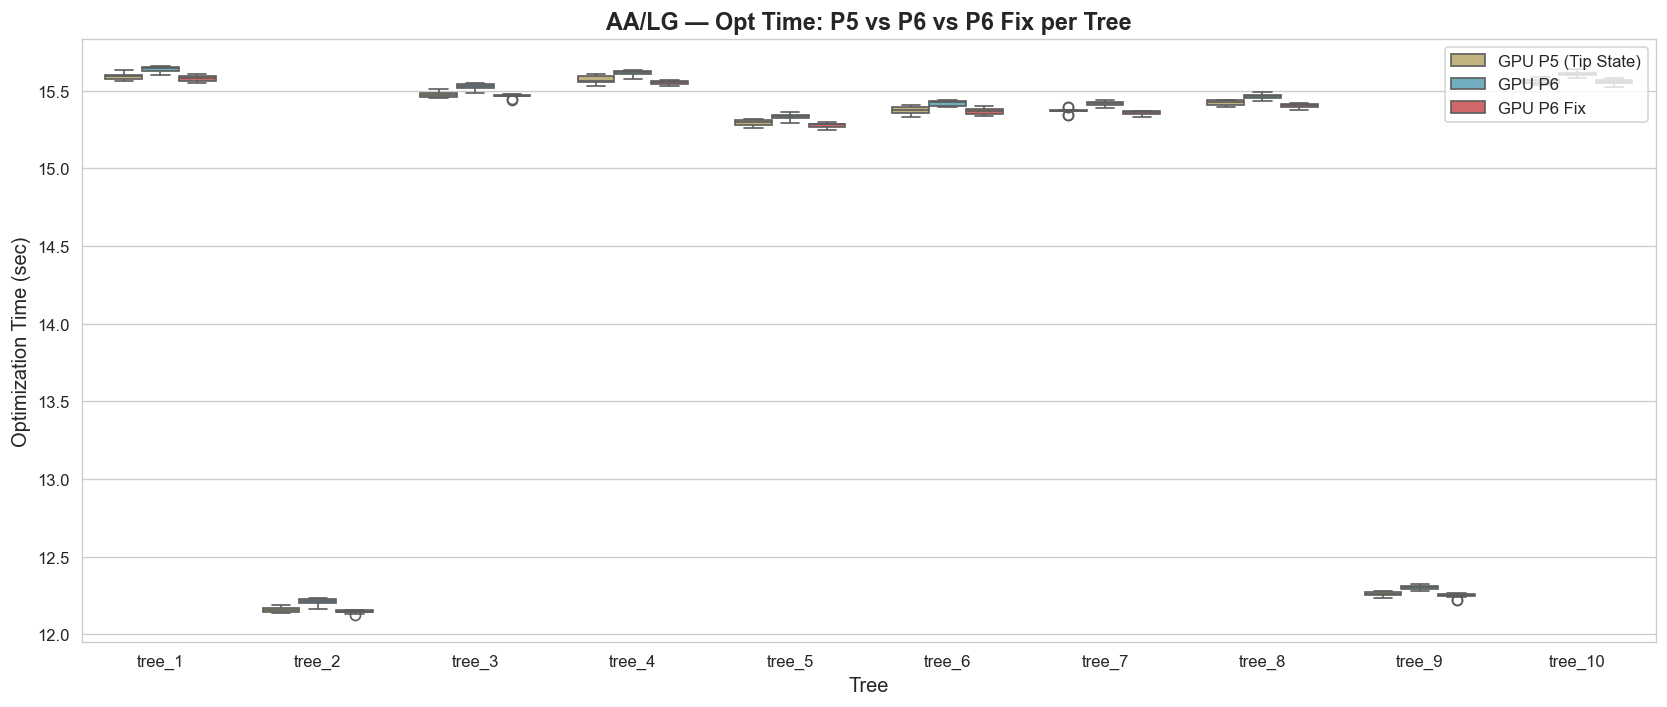

Saved: opt_p5_p6_p6fix_AA_LG.png


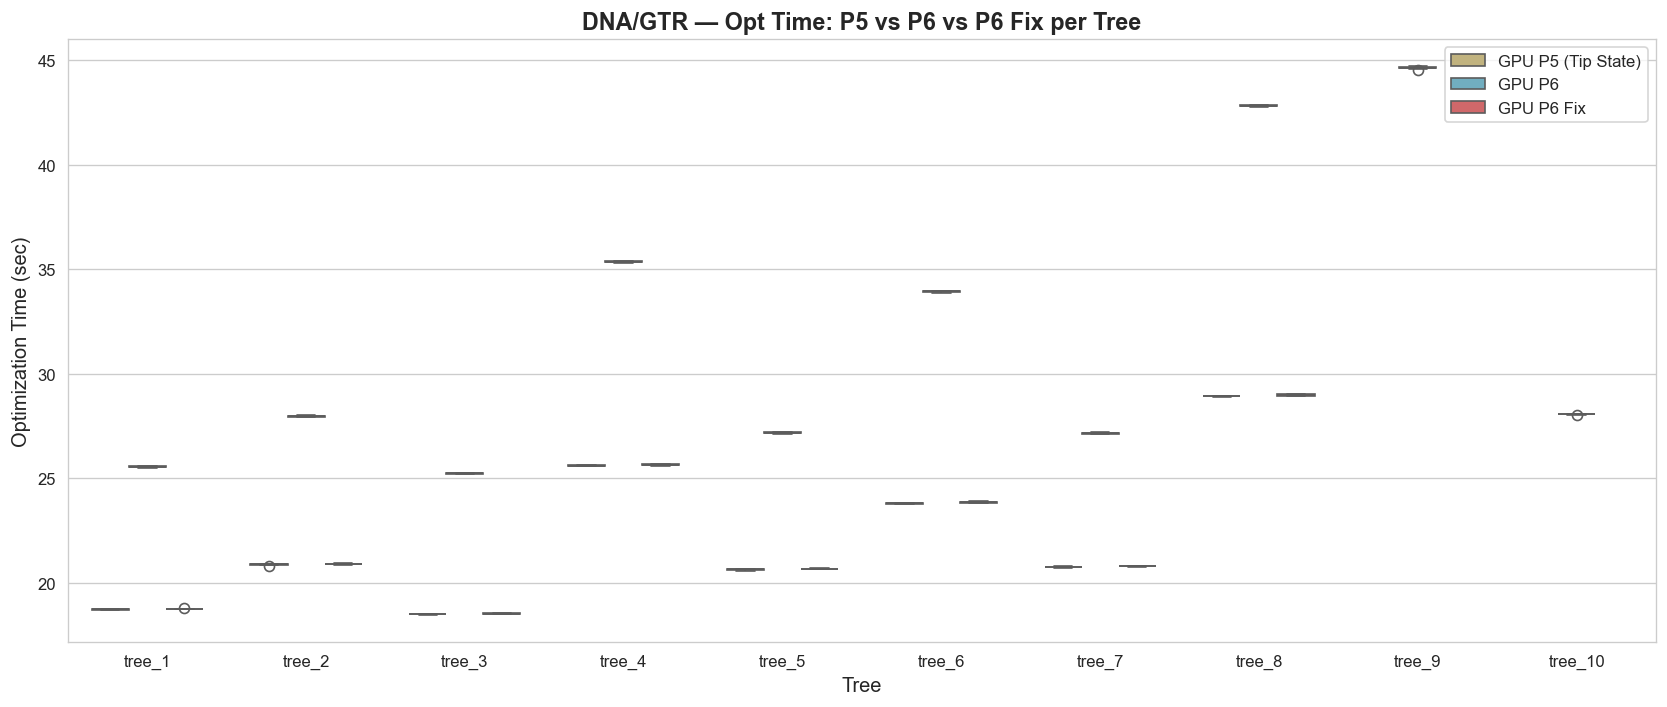

Saved: opt_p5_p6_p6fix_DNA_GTR.png


In [9]:
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(['GPU_P5', 'GPU_P6', 'GPU_P6_FIX'])]
    if subset.empty: continue
    
    trees = sorted(subset['tree'].unique(), key=lambda x: int(x.split('_')[1]))
    
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.boxplot(data=subset, x='tree', y='opt_time', hue='backend',
               order=trees, hue_order=['GPU_P5', 'GPU_P6', 'GPU_P6_FIX'],
               palette=[backend_colors['GPU_P5'], backend_colors['GPU_P6'], backend_colors['GPU_P6_FIX']],
               ax=ax, width=0.7)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['GPU P5 (Tip State)', 'GPU P6', 'GPU P6 Fix'], fontsize=10, loc='upper right')
    ax.set_xlabel('Tree', fontsize=12)
    ax.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax.set_title(f'{data_type}/{model} — Opt Time: P5 vs P6 vs P6 Fix per Tree',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'opt_p5_p6_p6fix_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 8. Optimization Rounds Analysis

How many optimization rounds (iterations) does each backend take? More rounds = more likelihood kernel calls.

In [10]:
# Parse optimization rounds from raw log files
import re
from pathlib import Path

def parse_opt_rounds(filepath):
    """Extract number of optimization rounds from log file."""
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except Exception:
        return None
    m = re.search(r'Parameters optimization took (\d+) rounds', text)
    if m:
        return int(m.group(1))
    return None

def parse_initial_logl(filepath):
    """Extract initial log-likelihood (before optimization)."""
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except Exception:
        return None
    m = re.search(r'Initial log-likelihood:\s*([-\d.]+)', text)
    if m:
        return float(m.group(1))
    return None

def parse_per_round_time(filepath):
    """Extract wall-clock time of first likelihood eval from log."""
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except Exception:
        return None
    m = re.search(r'Initial log-likelihood:.*?\(took\s+([-\d.]+)\s+wall-clock sec\)', text)
    if m:
        return float(m.group(1))
    return None

# Re-parse from raw log files to get rounds info
result_dirs = {
    'GPU_P6_FIX': Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_p6_step_fix'),
    'GPU_P6': Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_p6_step'),
    'GPU_P5': Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_persistent_tip_state'),
    'GPU_MAXREG': Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation_opt'),
    'BASELINE': Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation'),
}

def classify_backend(filename):
    if 'OPENACC' in filename: return 'OPENACC'
    elif 'VANILA' in filename: return 'VANILA'
    elif 'OMP_48' in filename: return 'OMP_48'
    elif 'OMP_10' in filename: return 'OMP_10'
    return 'UNKNOWN'

rounds_rows = []
for label, base_dir in result_dirs.items():
    for data_type in ['AA', 'DNA']:
        for tree_type in ['unrooted']:
            type_dir = base_dir / data_type / tree_type
            if not type_dir.exists(): continue
            for model_dir in sorted(type_dir.iterdir()):
                if not model_dir.is_dir(): continue
                model = model_dir.name
                if not ((data_type == 'AA' and model == 'LG') or (data_type == 'DNA' and model == 'GTR')):
                    continue
                for tree_dir in sorted(model_dir.iterdir()):
                    if not tree_dir.is_dir(): continue
                    tree = tree_dir.name
                    for logfile in tree_dir.glob('*.log'):
                        fname = logfile.name
                        if 'profile' in fname.lower(): continue
                        if label == 'BASELINE':
                            backend = classify_backend(fname)
                        elif label == 'GPU_P6_FIX':
                            bk = classify_backend(fname)
                            if bk == 'VANILA': continue  # skip VANILA in p6fix dir
                            backend = 'GPU_P6_FIX'
                        else:
                            backend = label
                        
                        rounds = parse_opt_rounds(logfile)
                        init_logl = parse_initial_logl(logfile)
                        first_eval = parse_per_round_time(logfile)
                        if rounds is not None:
                            rounds_rows.append({
                                'data_type': data_type, 'model': model, 'tree': tree,
                                'backend': backend, 'rounds': rounds,
                                'init_logl': init_logl, 'first_eval_sec': first_eval,
                                'filename': fname
                            })

df_rounds = pd.DataFrame(rounds_rows)
print(f'Parsed {len(df_rounds)} log files for rounds info')
print()
print('Optimization rounds by backend:')
print(df_rounds.groupby(['data_type', 'backend']).agg(
    rounds_mean=('rounds', 'mean'),
    rounds_median=('rounds', 'median'),
    rounds_min=('rounds', 'min'),
    rounds_max=('rounds', 'max'),
    first_eval_mean=('first_eval_sec', 'mean'),
    first_eval_median=('first_eval_sec', 'median'),
    n=('rounds', 'count')
).round(3).to_string())

Parsed 1364 log files for rounds info

Optimization rounds by backend:
                      rounds_mean  rounds_median  rounds_min  rounds_max  first_eval_mean  first_eval_median    n
data_type backend                                                                                                
AA        GPU_MAXREG        1.000            1.0           1           1            0.577              0.576   70
          GPU_P5            1.000            1.0           1           1            0.555              0.556   99
          GPU_P6            1.000            1.0           1           1            0.584              0.587  100
          GPU_P6_FIX        1.000            1.0           1           1            0.548              0.549   98
          OMP_10            1.000            1.0           1           1              NaN                NaN  100
          OMP_48            1.000            1.0           1           1              NaN                NaN  100
          OPENACC

In [11]:
# Per-round cost = opt_time / rounds
# Merge rounds into main df
df_merged = df.merge(
    df_rounds.groupby(['data_type', 'model', 'tree', 'backend']).agg(
        rounds_median=('rounds', 'median'),
        first_eval_median=('first_eval_sec', 'median')
    ).reset_index(),
    on=['data_type', 'model', 'tree', 'backend'],
    how='left'
)
df_merged['cost_per_round'] = df_merged['opt_time'] / df_merged['rounds_median']

print('=== Per-Round Cost (opt_time / rounds) ===')
per_round = df_merged.groupby(['data_type', 'backend']).agg(
    opt_median=('opt_time', 'median'),
    rounds_median=('rounds_median', 'median'),
    cost_per_round_median=('cost_per_round', 'median'),
    first_eval_median=('first_eval_median', 'median'),
    n=('cost_per_round', 'count')
).round(3)
print(per_round.to_string())
per_round.to_csv(SAVE_DIR / 'opt_per_round_cost.csv')

=== Per-Round Cost (opt_time / rounds) ===
                      opt_median  rounds_median  cost_per_round_median  first_eval_median    n
data_type backend                                                                             
AA        GPU_MAXREG      27.390            1.0                 27.390              0.579   70
          GPU_P5          15.397            1.0                 15.397              0.561   99
          GPU_P6          15.439            1.0                 15.439              0.590  100
          GPU_P6_FIX      15.382            1.0                 15.382              0.554   98
          OMP_10          37.316            1.0                 37.316                NaN  100
          OMP_48          13.586            1.0                 13.586                NaN  100
          OPENACC         27.728            1.0                 27.728              0.579  137
          VANILA         247.279            1.0                247.279                NaN   20
DNA    

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/4163050641.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='cost_per_round',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/4163050641.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=8)


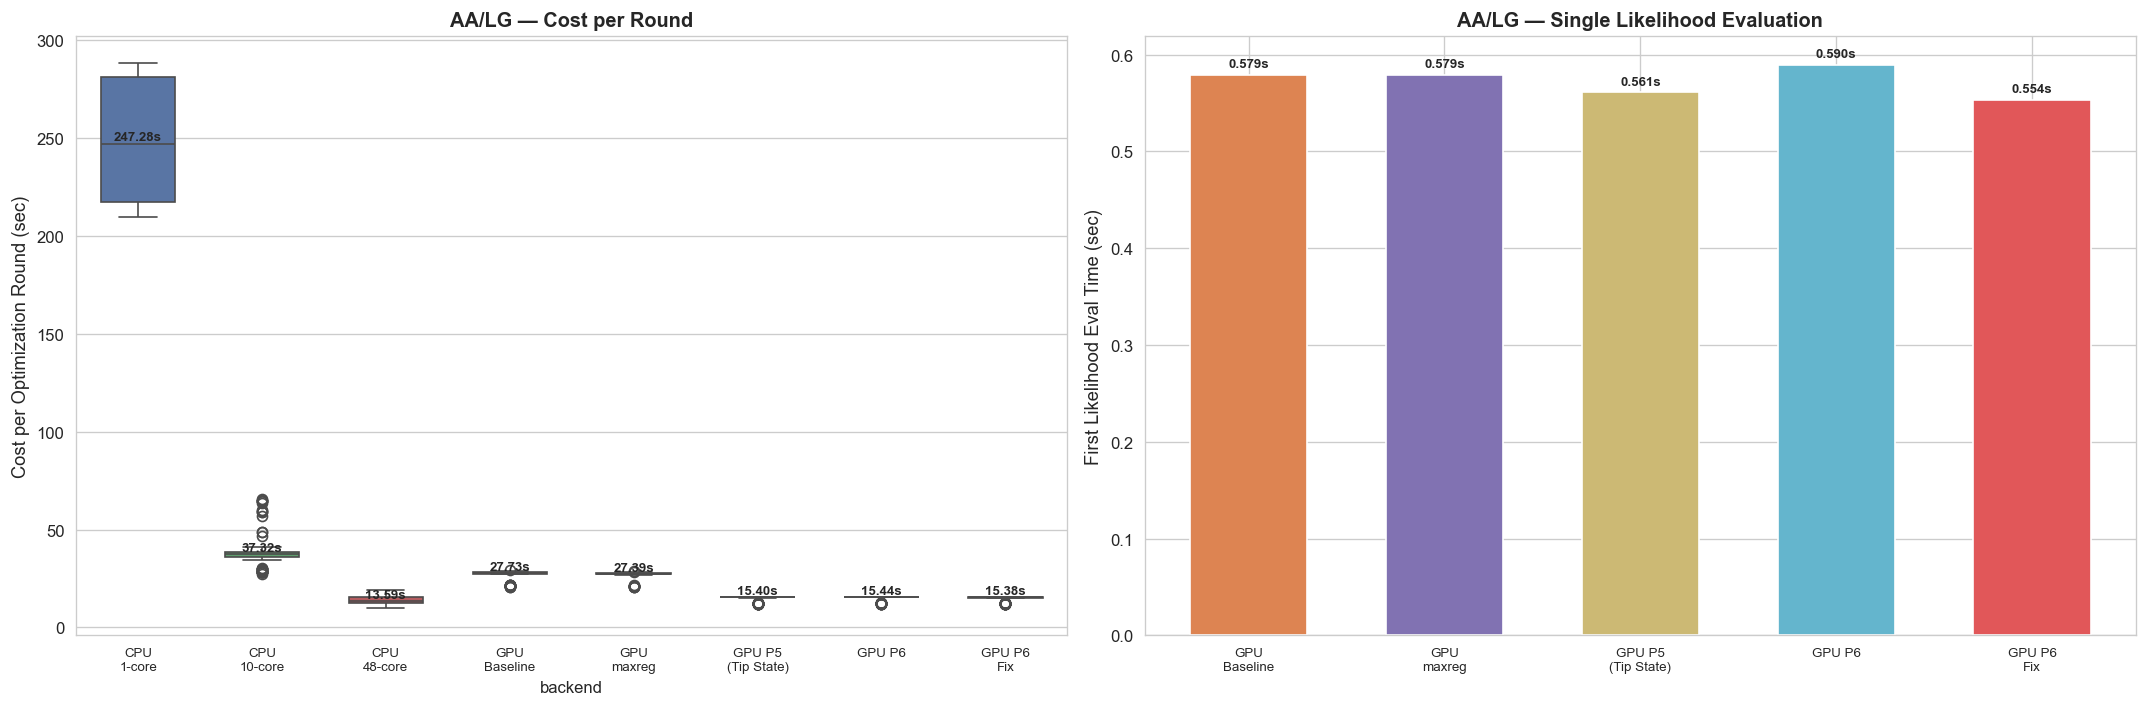

Saved: opt_per_round_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/4163050641.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='cost_per_round',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_49161/4163050641.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=8)


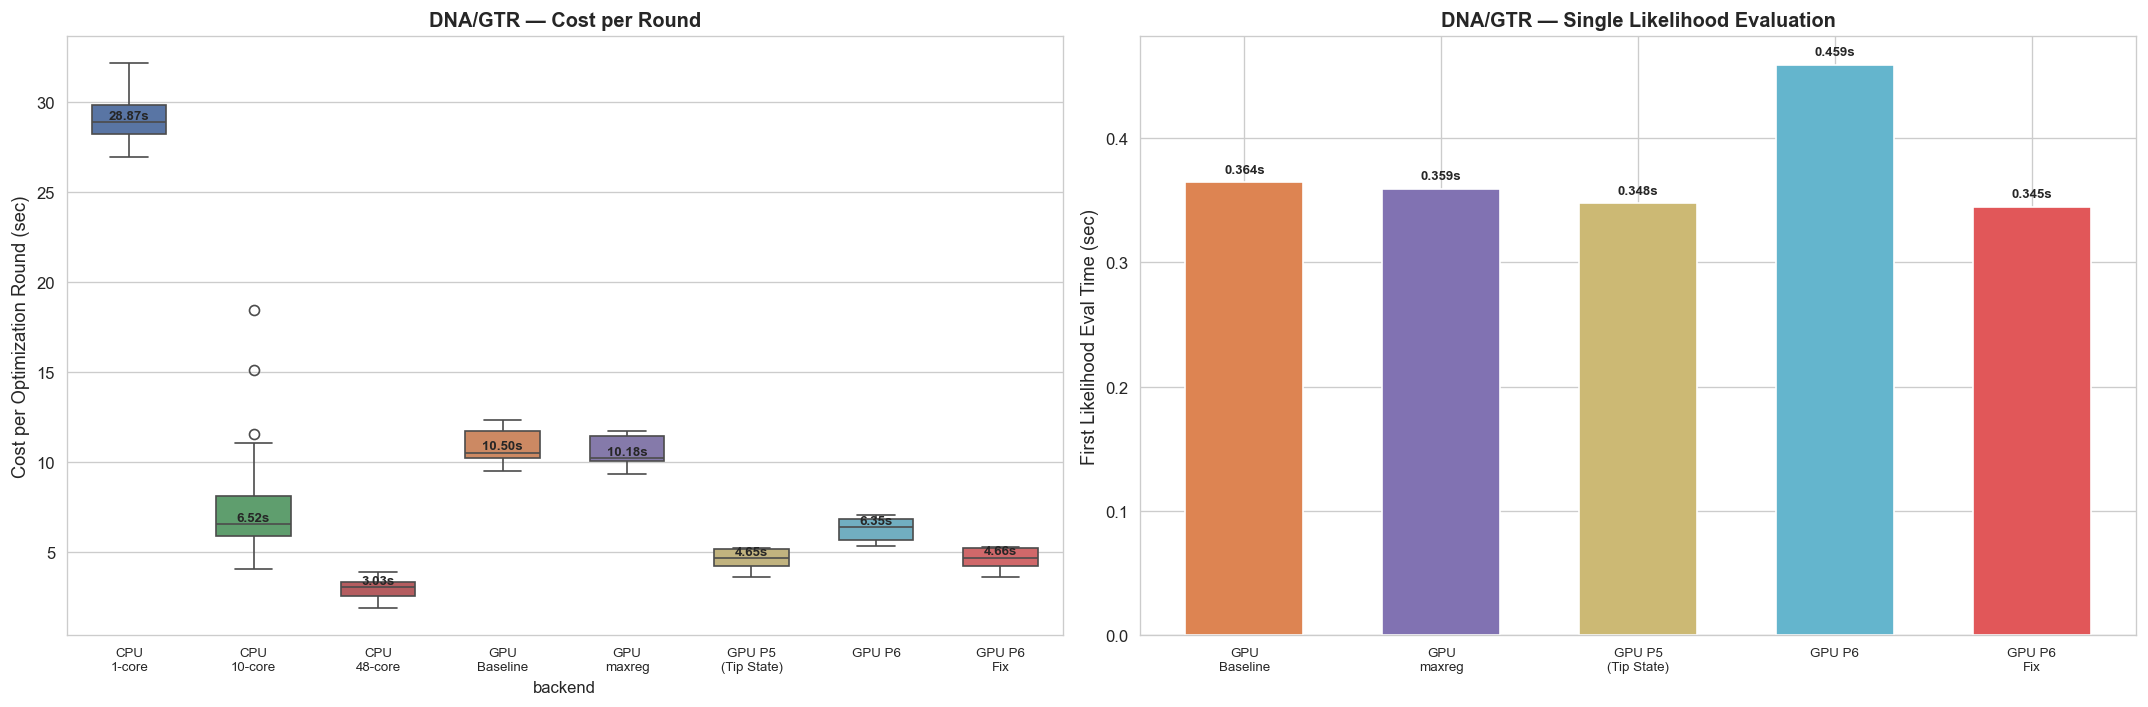

Saved: opt_per_round_DNA_GTR.png


In [12]:
# Visualize: first likelihood evaluation time (single kernel call) and per-round cost
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df_merged[(df_merged['data_type'] == data_type) & (df_merged['model'] == model)].dropna(subset=['cost_per_round'])
    present = [b for b in backend_order if b in subset['backend'].unique()]
    palette = [backend_colors[b] for b in present]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # Left: per-round cost
    sns.boxplot(data=subset, x='backend', y='cost_per_round',
               order=present, palette=palette, ax=ax1, width=0.6)
    ax1.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=8)
    ax1.set_ylabel('Cost per Optimization Round (sec)', fontsize=11)
    ax1.set_title(f'{data_type}/{model} — Cost per Round', fontsize=12, fontweight='bold')
    medians = subset.groupby('backend')['cost_per_round'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax1.text(i, medians[b] + 0.02, f'{medians[b]:.2f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    # Right: first eval time (single likelihood computation)
    subset_fe = subset.dropna(subset=['first_eval_median'])
    present_fe = [b for b in present if b in subset_fe['backend'].unique()]
    palette_fe = [backend_colors[b] for b in present_fe]
    if len(present_fe) > 0:
        med_fe = subset_fe.groupby('backend')['first_eval_median'].median().reindex(present_fe)
        bars = ax2.bar(range(len(present_fe)), med_fe.values,
                       color=palette_fe, width=0.6)
        for i, (b, val) in enumerate(zip(present_fe, med_fe.values)):
            ax2.text(i, val + 0.005, f'{val:.3f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=8)
        ax2.set_xticks(range(len(present_fe)))
        ax2.set_xticklabels([backend_labels.get(b, b) for b in present_fe], fontsize=8)
        ax2.set_ylabel('First Likelihood Eval Time (sec)', fontsize=11)
        ax2.set_title(f'{data_type}/{model} — Single Likelihood Evaluation', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    fname = f'opt_per_round_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 9. Optimization Time Gap Analysis — Where Is the Time?

In [13]:
# Summary table: where does each component contribute?
print('=' * 90)
print('OPTIMIZATION TIME GAP ANALYSIS')
print('=' * 90)

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    print(f'\n{"=" * 40}')
    print(f'{data_type}/{model}')
    print(f'{"=" * 40}')
    
    sub = df[(df['data_type'] == data_type) & (df['model'] == model)]
    
    backends_show = ['OMP_48', 'GPU_P6_FIX', 'OPENACC']
    for b in backends_show:
        bsub = sub[sub['backend'] == b]
        if bsub.empty: continue
        print(f'\n  {b}:')
        print(f'    Walltime median:  {bsub["walltime"].median():.2f}s')
        print(f'    Opt time median:  {bsub["opt_time"].median():.2f}s')
        print(f'    Overhead median:  {bsub["overhead"].median():.2f}s')
        print(f'    Opt % of wall:    {bsub["opt_pct"].median():.1f}%')
    
    # Gap calculations
    gpu_fix = sub[sub['backend'] == 'GPU_P6_FIX']
    cpu48 = sub[sub['backend'] == 'OMP_48']
    gpu_base = sub[sub['backend'] == 'OPENACC']
    
    if not gpu_fix.empty and not cpu48.empty:
        opt_gap = gpu_fix['opt_time'].median() - cpu48['opt_time'].median()
        oh_gap = gpu_fix['overhead'].median() - cpu48['overhead'].median()
        wall_gap = gpu_fix['walltime'].median() - cpu48['walltime'].median()
        print(f'\n  GAP: GPU P6 Fix vs CPU 48-core:')
        print(f'    Total walltime gap:    {wall_gap:+.2f}s')
        print(f'      - Opt time gap:      {opt_gap:+.2f}s  ({abs(opt_gap)/abs(wall_gap)*100:.0f}% of total gap)')
        print(f'      - Overhead gap:      {oh_gap:+.2f}s  ({abs(oh_gap)/abs(wall_gap)*100:.0f}% of total gap)')
    
    if not gpu_fix.empty and not gpu_base.empty:
        opt_imp = gpu_base['opt_time'].median() - gpu_fix['opt_time'].median()
        oh_imp = gpu_base['overhead'].median() - gpu_fix['overhead'].median()
        wall_imp = gpu_base['walltime'].median() - gpu_fix['walltime'].median()
        print(f'\n  IMPROVEMENT: GPU P6 Fix vs GPU Baseline:')
        print(f'    Total walltime saved:  {wall_imp:+.2f}s')
        print(f'      - Opt time saved:    {opt_imp:+.2f}s  ({abs(opt_imp)/abs(wall_imp)*100:.0f}% of total savings)')
        print(f'      - Overhead saved:    {oh_imp:+.2f}s  ({abs(oh_imp)/abs(wall_imp)*100:.0f}% of total savings)')

OPTIMIZATION TIME GAP ANALYSIS

AA/LG

  OMP_48:
    Walltime median:  15.02s
    Opt time median:  13.59s
    Overhead median:  1.39s
    Opt % of wall:    90.5%

  GPU_P6_FIX:
    Walltime median:  18.28s
    Opt time median:  15.38s
    Overhead median:  2.89s
    Opt % of wall:    84.2%

  OPENACC:
    Walltime median:  30.60s
    Opt time median:  27.73s
    Overhead median:  2.88s
    Opt % of wall:    90.6%

  GAP: GPU P6 Fix vs CPU 48-core:
    Total walltime gap:    +3.26s
      - Opt time gap:      +1.80s  (55% of total gap)
      - Overhead gap:      +1.50s  (46% of total gap)

  IMPROVEMENT: GPU P6 Fix vs GPU Baseline:
    Total walltime saved:  +12.32s
      - Opt time saved:    +12.35s  (100% of total savings)
      - Overhead saved:    -0.01s  (0% of total savings)

DNA/GTR

  OMP_48:
    Walltime median:  15.05s
    Opt time median:  13.61s
    Overhead median:  1.10s
    Opt % of wall:    92.5%

  GPU_P6_FIX:
    Walltime median:  23.63s
    Opt time median:  20.85s
  

## 10. Final Summary — Optimization Time Focus

In [14]:
final = df.groupby(['data_type', 'model', 'backend']).agg(
    walltime_median=('walltime', 'median'),
    opt_time_median=('opt_time', 'median'),
    overhead_median=('overhead', 'median'),
    opt_pct_median=('opt_pct', 'median'),
    n=('walltime', 'count')
).round(2).reset_index()

# Speedup columns based on opt_time
for ref_name, ref_backend in [('vs_1core', 'VANILA'), ('vs_cpu48', 'OMP_48'), ('vs_gpu_base', 'OPENACC')]:
    ref = final[final['backend'] == ref_backend][['data_type', 'model', 'opt_time_median']].rename(
        columns={'opt_time_median': 'ref'})
    final = final.merge(ref, on=['data_type', 'model'], how='left')
    final[f'opt_speedup_{ref_name}'] = (final['ref'] / final['opt_time_median']).round(2)
    final.drop(columns='ref', inplace=True)

final.to_csv(SAVE_DIR / 'opt_time_final_summary.csv', index=False)

print('=== Final Summary: Optimization Time Analysis ===')
print()
display(final.style.format({
    'opt_speedup_vs_1core': '{:.2f}x',
    'opt_speedup_vs_cpu48': '{:.2f}x',
    'opt_speedup_vs_gpu_base': '{:.2f}x',
    'opt_pct_median': '{:.1f}%'
}).background_gradient(subset=['opt_speedup_vs_cpu48'], cmap='RdYlGn', vmin=0.5, vmax=2.0)
 .background_gradient(subset=['opt_speedup_vs_gpu_base'], cmap='Oranges')
 .background_gradient(subset=['opt_time_median'], cmap='YlOrRd_r'))

=== Final Summary: Optimization Time Analysis ===



,data_type,model,backend,walltime_median,opt_time_median,overhead_median,opt_pct_median,n,opt_speedup_vs_1core,opt_speedup_vs_cpu48,opt_speedup_vs_gpu_base
0,AA,LG,GPU_MAXREG,30.250000,27.390000,2.880000,90.5%,70,9.03x,0.50x,1.01x
1,AA,LG,GPU_P5,18.290000,15.400000,2.860000,84.3%,99,16.06x,0.88x,1.80x
2,AA,LG,GPU_P6,18.310000,15.440000,2.850000,84.4%,100,16.02x,0.88x,1.80x
3,AA,LG,GPU_P6_FIX,18.280000,15.380000,2.890000,84.2%,98,16.08x,0.88x,1.80x
4,AA,LG,OMP_10,38.560000,37.320000,1.280000,96.7%,100,6.63x,0.36x,0.74x
5,AA,LG,OMP_48,15.020000,13.590000,1.390000,90.5%,100,18.20x,1.00x,2.04x
6,AA,LG,OPENACC,30.600000,27.730000,2.880000,90.6%,137,8.92x,0.49x,1.00x
7,AA,LG,VANILA,250.290000,247.280000,2.990000,98.8%,20,1.00x,0.05x,0.11x
8,DNA,GTR,GPU_MAXREG,48.260000,45.570000,2.760000,94.3%,50,2.62x,0.30x,1.02x
9,DNA,GTR,GPU_P5,23.620000,20.810000,2.800000,88.2%,80,5.73x,0.65x,2.24x


## 11. Conclusions

In [15]:
print('=' * 80)
print('CONCLUSIONS — Optimization Time Analysis')
print('=' * 80)

# Calculate key metrics
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    sub = df[(df['data_type'] == data_type) & (df['model'] == model)]
    gpu_fix = sub[sub['backend'] == 'GPU_P6_FIX']
    gpu_base = sub[sub['backend'] == 'OPENACC']
    cpu48 = sub[sub['backend'] == 'OMP_48']
    gpu_p5 = sub[sub['backend'] == 'GPU_P5']
    
    print(f'\n--- {data_type}/{model} ---')
    
    # Opt time values
    opt_fix = gpu_fix['opt_time'].median()
    opt_base = gpu_base['opt_time'].median()
    opt_48 = cpu48['opt_time'].median()
    opt_p5 = gpu_p5['opt_time'].median()
    
    # Overhead values
    oh_fix = gpu_fix['overhead'].median()
    oh_48 = cpu48['overhead'].median()
    
    imp_vs_base = (opt_base - opt_fix) / opt_base * 100
    gap_vs_48 = (opt_fix - opt_48) / opt_48 * 100
    
    print(f'  GPU P6 Fix opt_time:     {opt_fix:.1f}s')
    print(f'  GPU Baseline opt_time:   {opt_base:.1f}s  -> P6 Fix is {imp_vs_base:.0f}% faster')
    print(f'  CPU 48-core opt_time:    {opt_48:.1f}s  -> GPU still {gap_vs_48:.0f}% slower')
    print(f'  GPU P5 opt_time:         {opt_p5:.1f}s  -> P6 Fix = P5 (no change)')
    print(f'  Overhead: GPU={oh_fix:.2f}s, CPU48={oh_48:.2f}s (GPU +{oh_fix - oh_48:.2f}s extra)')

print(f'\n{"=" * 80}')
print('KEY FINDINGS:')
print('=' * 80)
print()
print('1. OPTIMIZATION TIME DOMINATES: 84-88% of GPU walltime is in parameter optimization.')
print('   The overhead (setup, I/O) is small and similar across GPU builds (~2.8-2.9s).')
print()
print('2. P5 WAS THE BREAKTHROUGH, P6/P6 Fix ADDED NOTHING:')
print('   P5 (Persistent Tip State) halved the optimization time.')
print('   P6 and P6 Fix have identical opt_time to P5.')
print()
print('3. GPU IS STILL SLOWER THAN CPU 48-CORE IN PURE OPTIMIZATION:')

# AA gap
sub_aa = df[(df['data_type'] == 'AA') & (df['model'] == 'LG')]
aa_gap = (sub_aa[sub_aa['backend'] == 'GPU_P6_FIX']['opt_time'].median() / 
          sub_aa[sub_aa['backend'] == 'OMP_48']['opt_time'].median())
print(f'   AA/LG:  GPU is {aa_gap:.2f}x of CPU 48-core ({(aa_gap-1)*100:.0f}% slower)')

sub_dna = df[(df['data_type'] == 'DNA') & (df['model'] == 'GTR')]
dna_gap = (sub_dna[sub_dna['backend'] == 'GPU_P6_FIX']['opt_time'].median() /
           sub_dna[sub_dna['backend'] == 'OMP_48']['opt_time'].median())
print(f'   DNA/GTR: GPU is {dna_gap:.2f}x of CPU 48-core ({(dna_gap-1)*100:.0f}% slower)')

print()
print('4. OVERHEAD GAP IS SMALL BUT REAL:')
print('   GPU overhead ~2.9s vs CPU ~1.3s (+1.6s for GPU init/transfer).')
print('   But this is <10% of total — the kernel is the bottleneck.')
print()
print('5. TO BEAT CPU 48-CORE, THE GPU LIKELIHOOD KERNEL MUST GET FASTER.')
print('   No amount of overhead reduction will close the gap.')
print(f'   AA/LG needs:  opt_time < {sub_aa[sub_aa["backend"]=="OMP_48"]["opt_time"].median():.1f}s (currently {sub_aa[sub_aa["backend"]=="GPU_P6_FIX"]["opt_time"].median():.1f}s)')
print(f'   DNA/GTR needs: opt_time < {sub_dna[sub_dna["backend"]=="OMP_48"]["opt_time"].median():.1f}s (currently {sub_dna[sub_dna["backend"]=="GPU_P6_FIX"]["opt_time"].median():.1f}s)')

CONCLUSIONS — Optimization Time Analysis

--- AA/LG ---
  GPU P6 Fix opt_time:     15.4s
  GPU Baseline opt_time:   27.7s  -> P6 Fix is 45% faster
  CPU 48-core opt_time:    13.6s  -> GPU still 13% slower
  GPU P5 opt_time:         15.4s  -> P6 Fix = P5 (no change)
  Overhead: GPU=2.89s, CPU48=1.39s (GPU +1.50s extra)

--- DNA/GTR ---
  GPU P6 Fix opt_time:     20.9s
  GPU Baseline opt_time:   46.6s  -> P6 Fix is 55% faster
  CPU 48-core opt_time:    13.6s  -> GPU still 53% slower
  GPU P5 opt_time:         20.8s  -> P6 Fix = P5 (no change)
  Overhead: GPU=2.78s, CPU48=1.10s (GPU +1.69s extra)

KEY FINDINGS:

1. OPTIMIZATION TIME DOMINATES: 84-88% of GPU walltime is in parameter optimization.
   The overhead (setup, I/O) is small and similar across GPU builds (~2.8-2.9s).

2. P5 WAS THE BREAKTHROUGH, P6/P6 Fix ADDED NOTHING:
   P5 (Persistent Tip State) halved the optimization time.
   P6 and P6 Fix have identical opt_time to P5.

3. GPU IS STILL SLOWER THAN CPU 48-CORE IN PURE OPTIMIZ